# 1. Load and Merge IPL Datasets

The IPL dataset consists of two separate files:

1. **matches.csv**
   Contains match-level information such as teams, venue, winner, toss details, and season.

2. **deliveries.csv**
    Contains ball-by-ball information for every delivery bowled in IPL history.

To perform detailed analysis, both datasets need to be combined into a single analytical DataFrame.

The common key between the two datasets is:

 `matches.id`
 `deliveries.match_id`

After merging, each delivery will contain both ball-level and match-level information, enabling comprehensive analysis.

In [1]:
import pandas as pd
import numpy as np

# Load datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches Dataset")
display(matches.head())

print("Deliveries Dataset")
display(deliveries.head())

Matches Dataset


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


Deliveries Dataset


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## Merging the Datasets

The deliveries dataset contains ball-by-ball records, while the matches dataset contains match-level information.

We perform a left join using:

- deliveries.match_id
- matches.id

This ensures every delivery retains its information while gaining match-level attributes.

In [2]:
ipl_df = deliveries.merge(
    matches,
    left_on='match_id',
    right_on='id',
    how='left'
)

ipl_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen


## Dataset Structure

After merging, we inspect:

 Shape of the dataset
 Column names
 Data types

This helps us understand the dimensions and identify potential cleaning requirements.

In [3]:
print("Shape of merged dataset:")
print(ipl_df.shape)

print("\nColumn Names:")
print(ipl_df.columns.tolist())

print("\nData Types:")
print(ipl_df.dtypes)

Shape of merged dataset:
(260920, 37)

Column Names:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Data Types:
match_id              int64
inning                int64
batting_team         object
bowling_team         object
over                  int64
ball                  int64
batter               object
bowler               object
non_striker          object
batsman_runs          int64
extra_runs            int64
total_runs            int64
extras_type          object
is_wicket             int64
player_dismissed     object
dismissal_kind       object
fielder              

## Number of Seasons Covered

To understand the historical coverage of the dataset, we calculate the number of unique IPL seasons available.

In [4]:
print("Seasons Covered:")

seasons = sorted(matches['season'].unique())

print(seasons)

print("\nTotal Seasons:", len(seasons))

Seasons Covered:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Total Seasons: 17


# 2. Handling Missing Values

Missing values can negatively affect analysis and visualizations.

We first identify columns containing null values and then decide appropriate treatments:


In [5]:
missing_values = ipl_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

method              257274
fielder             251566
player_dismissed    247970
dismissal_kind      247970
extras_type         246795
city                 12397
result_margin         4124
winner                 490
player_of_match        490
target_runs            309
target_overs           309
dtype: int64

## Handling Missing Values in City

The `city` column contains a small number of missing values.

Since venue information is still available and city is useful for venue analysis, dropping entire rows would result in unnecessary data loss.

Therefore, missing city values will be replaced with `"Unknown"`.

In [6]:
matches['city'] = matches['city'].fillna("Unknown")

## Handling Missing Values in Player of Match

The `player_of_match` field is missing for a few matches.

Removing these matches would discard useful information such as venue, teams, and match outcomes.

Therefore, missing values will be replaced with `"Not Awarded"`.

In [7]:
matches['player_of_match'] = matches['player_of_match'].fillna("Not Awarded")

## Handling Missing Values in Dismissal Kind

For deliveries where no wicket fell, the `dismissal_kind` column is empty.

Replacing null values with `"not out"` makes wicket analysis easier and improves readability.

In [8]:
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('not out')

## Verifying Missing Values

After cleaning, we verify that the handled columns no longer contain missing values.

In [9]:
print(matches[['city','player_of_match']].isnull().sum())

print(deliveries['dismissal_kind'].isnull().sum())

city               0
player_of_match    0
dtype: int64
0


# 3. Feature Engineering (NumPy & Pandas)

Feature engineering involves creating new variables from existing data to make analysis more meaningful.

In this section:

- Create a new column `total_runs` as the sum of batsman runs and extra runs.
- Use NumPy to classify deliveries as boundaries or non-boundaries.
- Categorize overs into Powerplay, Middle, and Death phases.
- Extract year and month from the match date for seasonal trend analysis.

These features will help us perform batting, scoring, and trend analyses later in the project.

In [10]:
deliveries['total_runs_calc'] = (
    deliveries['batsman_runs'] +
    deliveries['extra_runs']
)

deliveries[['batsman_runs', 'extra_runs', 'total_runs_calc']].head()

,batsman_runs,extra_runs,total_runs_calc
0,0,1,1
1,0,0,0
2,0,1,1
3,0,0,0
4,0,0,0


## Creating Boundary Indicator

A delivery is classified as a boundary if the batsman scores 4 or more runs from the bat.

Using NumPy's `where()` function allows efficient vectorized classification of all deliveries.

In [11]:
deliveries['is_boundary'] = np.where(
    deliveries['batsman_runs'] >= 4,
    'boundary',
    'non-boundary'
)

deliveries[['batsman_runs', 'is_boundary']].head()

,batsman_runs,is_boundary
0,0,non-boundary
1,0,non-boundary
2,0,non-boundary
3,0,non-boundary
4,0,non-boundary


## Creating Over Phases

Cricket innings are generally divided into three phases:

- Powerplay: Overs 1–6
- Middle Overs: Overs 7–15
- Death Overs: Overs 16–20

These phases have different scoring patterns and strategies.

In [12]:
def classify_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

deliveries['over_phase'] = deliveries['over'].apply(classify_phase)

deliveries[['over', 'over_phase']].head()

,over,over_phase
0,0,Powerplay
1,0,Powerplay
2,0,Powerplay
3,0,Powerplay
4,0,Powerplay


## Extracting Year and Month

The match date contains valuable temporal information.

Extracting year and month enables seasonal and monthly trend analysis of IPL matches.

In [13]:
matches['date'] = pd.to_datetime(matches['date'])

matches['year'] = matches['date'].dt.year
matches['month'] = matches['date'].dt.month

matches[['date', 'year', 'month']].head()

,date,year,month
0,2008-04-18,2008,4
1,2008-04-19,2008,4
2,2008-04-19,2008,4
3,2008-04-20,2008,4
4,2008-04-20,2008,4


## Verifying Newly Created Features

The newly engineered features are checked to ensure that they have been created correctly and are ready for analysis.

In [14]:
print("Boundary Counts:")
print(deliveries['is_boundary'].value_counts())

print("\nOver Phase Counts:")
print(deliveries['over_phase'].value_counts())

print("\nYears Covered:")
print(matches['year'].unique())

Boundary Counts:
is_boundary
non-boundary    217954
boundary         42966
Name: count, dtype: int64

Over Phase Counts:
over_phase
Middle       118979
Powerplay     95357
Death         46584
Name: count, dtype: int64

Years Covered:
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024]


# 4. Aggregations & Summary Statistics

Aggregation helps summarize large datasets into meaningful insights.

In this section, we will:

1. Identify the top 5 batsmen by total runs scored.
2. Calculate economy rates for bowlers who have bowled at least 500 deliveries.
3. Determine the team with the highest win percentage in each season.

These statistics provide insights into player performance and team success across IPL seasons.

## Top 5 Batsmen by Total Runs

A batsman's performance can be evaluated using the total runs scored across all IPL seasons.

We group deliveries by batsman and sum their runs to identify the leading run-scorers.

In [15]:
top_batsmen = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_batsmen

batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64

In [16]:
top_batsmen_df = top_batsmen.reset_index()

top_batsmen_df.columns = ['Batsman', 'Total Runs']

top_batsmen_df

,Batsman,Total Runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536


### Interpretation

The table shows the five highest run-scorers in IPL history.

These players have consistently performed across multiple seasons and contributed significantly to their teams' batting success.

## Economy Rate Analysis

Economy rate measures the average number of runs conceded per over.

Formula:

Economy Rate = Runs Conceded / Overs Bowled

To avoid misleading results from bowlers with very few deliveries, only bowlers who have bowled at least 500 balls are considered.

In [17]:
bowler_stats = deliveries.groupby('bowler').agg(
    balls_bowled=('ball', 'count'),
    runs_conceded=('total_runs', 'sum')
)

bowler_stats = bowler_stats[
    bowler_stats['balls_bowled'] >= 500
]

Using NumPy, overs bowled and economy rates are calculated efficiently through vectorized operations.

In [18]:
bowler_stats['overs_bowled'] = np.round(
    bowler_stats['balls_bowled'] / 6,
    2
)

bowler_stats['economy_rate'] = np.round(
    bowler_stats['runs_conceded'] /
    bowler_stats['overs_bowled'],
    2
)

economy_df = (
    bowler_stats
    .sort_values('economy_rate')
)

economy_df.head(10)

,balls_bowled,runs_conceded,overs_bowled,economy_rate
bowler,,,,
A Kumble,983,1089,163.83,6.65
M Muralitharan,1581,1765,263.50,6.70
SP Narine,4146,4672,691.00,6.76
DW Steyn,2282,2583,380.33,6.79
DL Vettori,785,894,130.83,6.83
Rashid Khan,2901,3340,483.50,6.91
J Botha,709,818,118.17,6.92
R Ashwin,4679,5435,779.83,6.97
MM Ali,770,900,128.33,7.01


### Interpretation

Lower economy rates indicate better bowling performance because the bowler concedes fewer runs per over.

The table highlights the most economical bowlers among those with substantial bowling experience.

## Highest Win Percentage by Season

Win percentage provides a better measure of team performance than total wins because teams may play different numbers of matches.

For each season:

Win Percentage = (Matches Won / Matches Played) × 100

The team with the highest percentage in each season is identified.

In [19]:
teams = pd.concat([
    matches[['season', 'team1']]
        .rename(columns={'team1':'team'}),
    matches[['season', 'team2']]
        .rename(columns={'team2':'team'})
])

matches_played = (
    teams.groupby(['season','team'])
    .size()
    .reset_index(name='matches_played')
)

In [20]:
wins = (
    matches.groupby(['season','winner'])
    .size()
    .reset_index(name='matches_won')
)

wins = wins.rename(
    columns={'winner':'team'}
)

In [21]:
season_stats = matches_played.merge(
    wins,
    on=['season','team'],
    how='left'
)

season_stats['matches_won'] = (
    season_stats['matches_won']
    .fillna(0)
)

season_stats['win_percentage'] = np.round(
    (
        season_stats['matches_won'] /
        season_stats['matches_played']
    ) * 100,
    2
)

season_stats.head()

,season,team,matches_played,matches_won,win_percentage
0,2007/08,Chennai Super Kings,16,9,56.25
1,2007/08,Deccan Chargers,14,2,14.29
2,2007/08,Delhi Daredevils,14,7,50.00
3,2007/08,Kings XI Punjab,15,10,66.67
4,2007/08,Kolkata Knight Riders,13,6,46.15


In [22]:
best_team_each_season = (
    season_stats.loc[
        season_stats.groupby('season')
        ['win_percentage']
        .idxmax()
    ]
)

best_team_each_season[
    ['season',
     'team',
     'matches_played',
     'matches_won',
     'win_percentage']
]

,season,team,matches_played,matches_won,win_percentage
6,2007/08,Rajasthan Royals,16,13,81.25
10,2009,Delhi Daredevils,15,10,66.67
21,2009/10,Mumbai Indians,16,11,68.75
24,2011,Chennai Super Kings,16,11,68.75
38,2012,Kolkata Knight Riders,17,12,70.59
47,2013,Mumbai Indians,19,13,68.42
54,2014,Kings XI Punjab,17,12,70.59
64,2015,Mumbai Indians,16,10,62.50
75,2016,Sunrisers Hyderabad,17,11,64.71
80,2017,Mumbai Indians,17,12,70.59


### Interpretation

The resulting table identifies the most successful team in each IPL season based on win percentage.

This metric accounts for differences in the number of matches played and provides a fair comparison across teams.

# Part B

# 5. Toss Impact on Match Outcome

Winning the toss allows a team to choose whether to bat or field first.

This analysis examines whether choosing to bat first or field first provides a significant advantage in winning matches.

In [23]:
toss_analysis = matches.copy()

toss_analysis['toss_win_match_win'] = (
    toss_analysis['toss_winner'] ==
    toss_analysis['winner']
)

decision_stats = (
    toss_analysis.groupby('toss_decision')
    ['toss_win_match_win']
    .mean()
    * 100
).reset_index()

decision_stats

,toss_decision,toss_win_match_win
0,bat,45.268542
1,field,53.551136


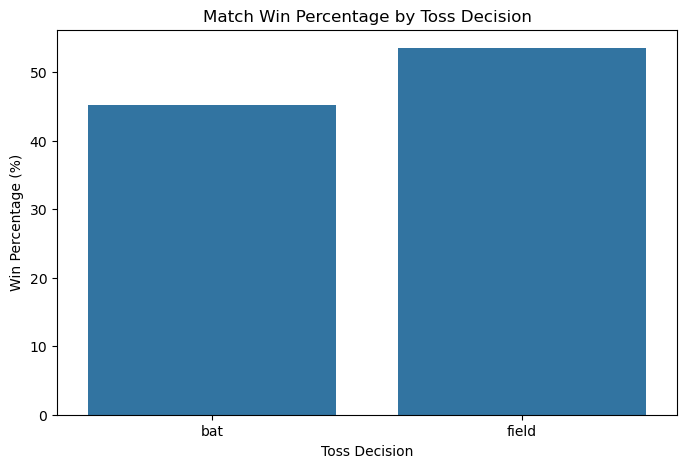

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=decision_stats,
    x='toss_decision',
    y='toss_win_match_win'
)

plt.title('Match Win Percentage by Toss Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Win Percentage (%)')

plt.show()

### Interpretation

The chart compares the percentage of matches won after choosing to bat first versus field first.

 a small difference would indicate that toss decisions alone do not strongly determine match outcomes.

# 6. Top Run-Scorers and Their Dismissal Patterns

Batting performance is evaluated through total runs scored.

This analysis identifies the top 10 IPL run-scorers and examines how the top three batsmen are dismissed.

In [25]:
top10_batsmen = (
    deliveries.groupby('batter')
    ['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_batsmen

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


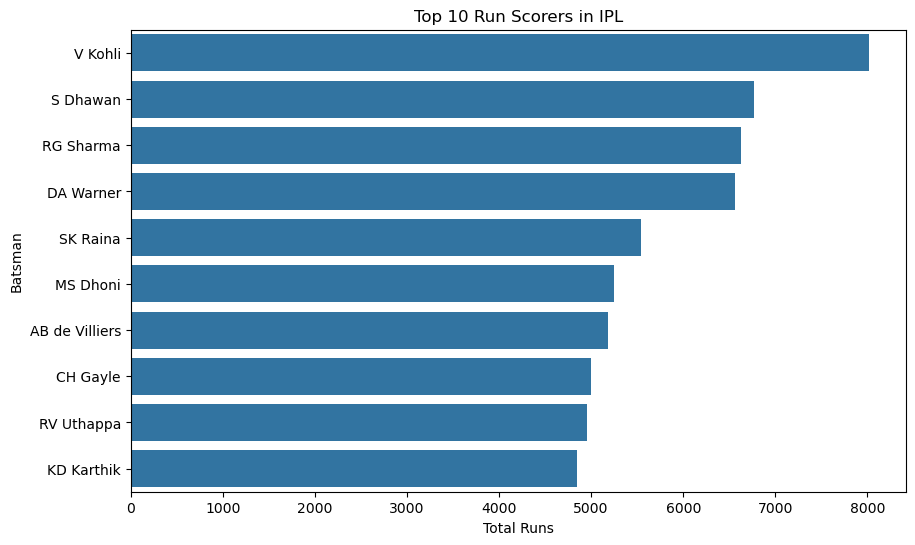

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_batsmen,
    x='batsman_runs',
    y='batter'
)

plt.title('Top 10 Run Scorers in IPL')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

plt.show()

### Interpretation

The chart highlights the most successful batsmen in IPL history.

These players have consistently contributed runs across multiple seasons, making them key performers for their respective teams.

In [27]:
top3 = top10_batsmen['batter'].head(3).tolist()

dismissal_data = deliveries[
    deliveries['batter'].isin(top3)
]

dismissal_data = dismissal_data[
    dismissal_data['dismissal_kind'] != 'not out'
]

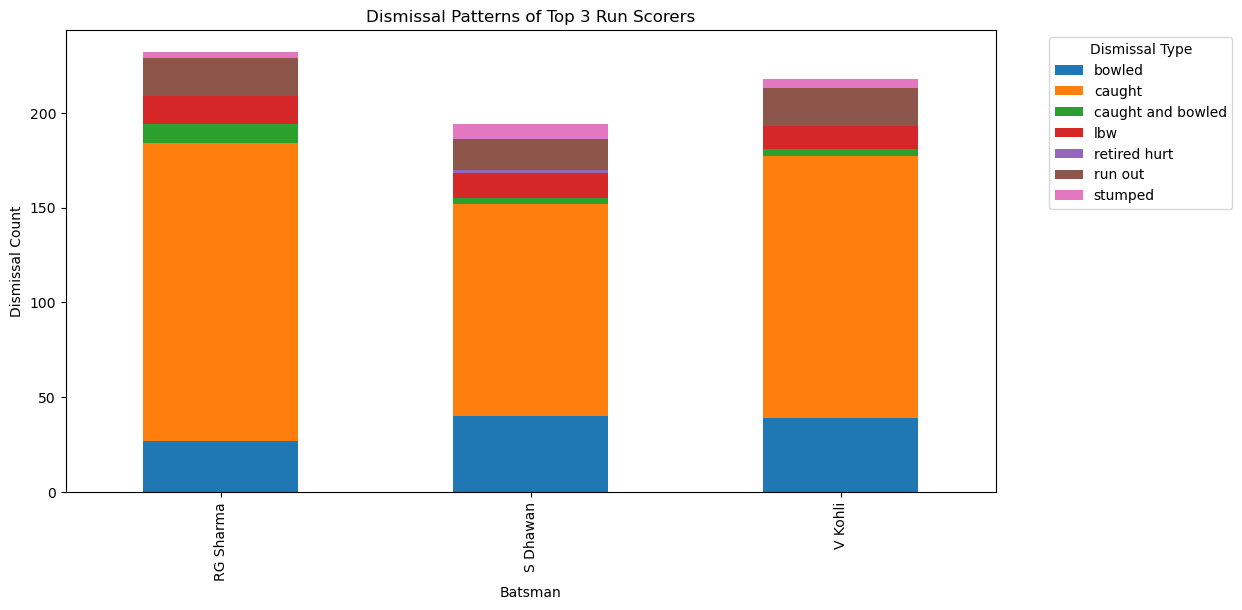

In [28]:
dismissal_summary = pd.crosstab(
    dismissal_data['batter'],
    dismissal_data['dismissal_kind']
)

dismissal_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Dismissal Patterns of Top 3 Run Scorers')
plt.xlabel('Batsman')
plt.ylabel('Dismissal Count')

plt.legend(title='Dismissal Type',
           bbox_to_anchor=(1.05,1))

plt.show()

### Interpretation

The stacked bar chart reveals the most common dismissal methods for the top three batsmen.

A higher proportion of dismissals such as caught or bowled may indicate specific weaknesses that opposing teams can exploit.

# 7. Seasonal Batting Trends

Batting trends can reveal how scoring patterns have evolved throughout IPL history.

We calculate average runs scored per match for each season and examine whether the IPL has become more high-scoring over time.

In [29]:
season_runs = (
    deliveries.groupby('match_id')
    ['total_runs']
    .sum()
    .reset_index()
)

season_runs = season_runs.merge(
    matches[['id','season']],
    left_on='match_id',
    right_on='id'
)

avg_runs = (
    season_runs.groupby('season')
    ['total_runs']
    .mean()
    .reset_index()
)

avg_runs

,season,total_runs
0,2007/08,309.258621
1,2009,286.894737
2,2009/10,314.716667
3,2011,289.780822
4,2012,303.418919
5,2013,297.394737
6,2014,315.516667
7,2015,311.067797
8,2016,314.366667
9,2017,318.406780


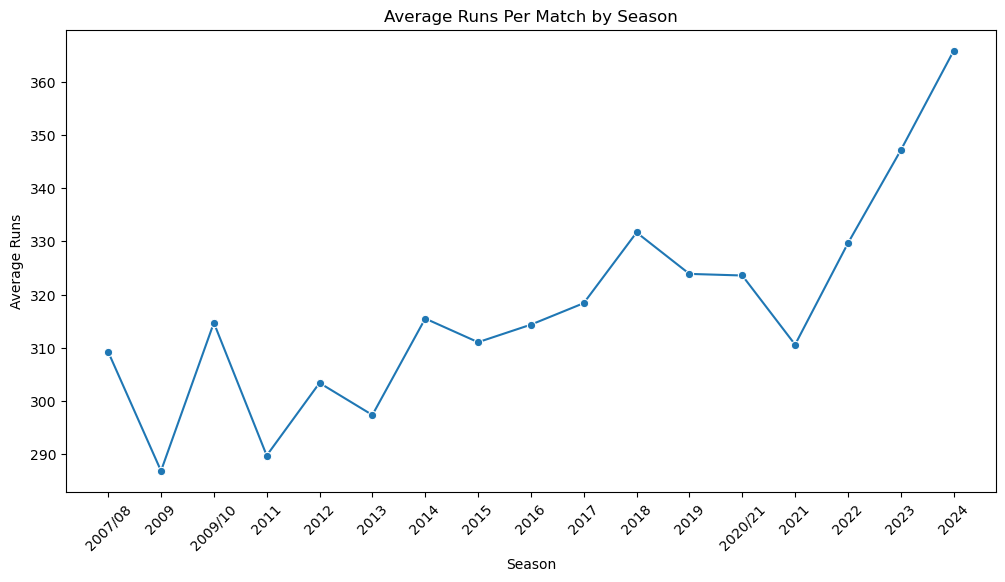

In [30]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=avg_runs,
    x='season',
    y='total_runs',
    marker='o'
)

plt.title('Average Runs Per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The line plot shows how average match scores have changed over different IPL seasons.

Spikes indicate particularly high-scoring seasons, while dips may reflect stronger bowling performances or changing playing conditions.

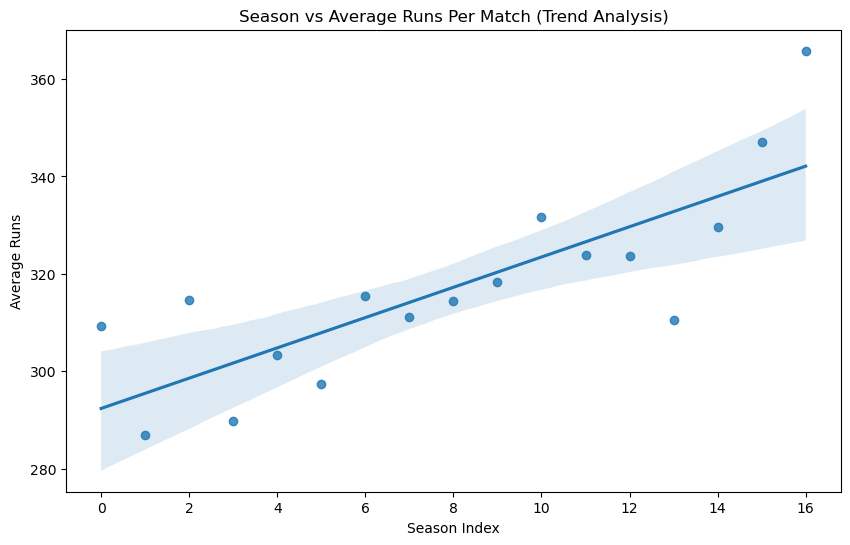

In [31]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=avg_runs,
    x=np.arange(len(avg_runs)),
    y='total_runs'
)

plt.title('Season vs Average Runs Per Match (Trend Analysis)')
plt.xlabel('Season Index')
plt.ylabel('Average Runs')

plt.show()

### Interpretation

The regression line helps identify long-term scoring trends.

An upward slope suggests that IPL matches have become increasingly high-scoring over time, potentially due to aggressive batting strategies and improved batting conditions.

# 8. Match Outcome and Venue Analysis

Different venues often favor particular teams due to pitch conditions, crowd support, and familiarity.

This analysis identifies the top 5 stadiums that have hosted the most IPL matches and examines the distribution of match winners at those venues.

In [32]:
top_venues = matches['venue'].value_counts().head(5)

top_venues

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Rajiv Gandhi International Stadium, Uppal    49
Name: count, dtype: int64

In [33]:
top_venue_names = top_venues.index.tolist()

venue_data = matches[
    matches['venue'].isin(top_venue_names)
]

venue_data.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year,month
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2008,4
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2008,4
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2008,4
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2008,4
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Daredevils,Deccan Chargers,...,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba,2008,4


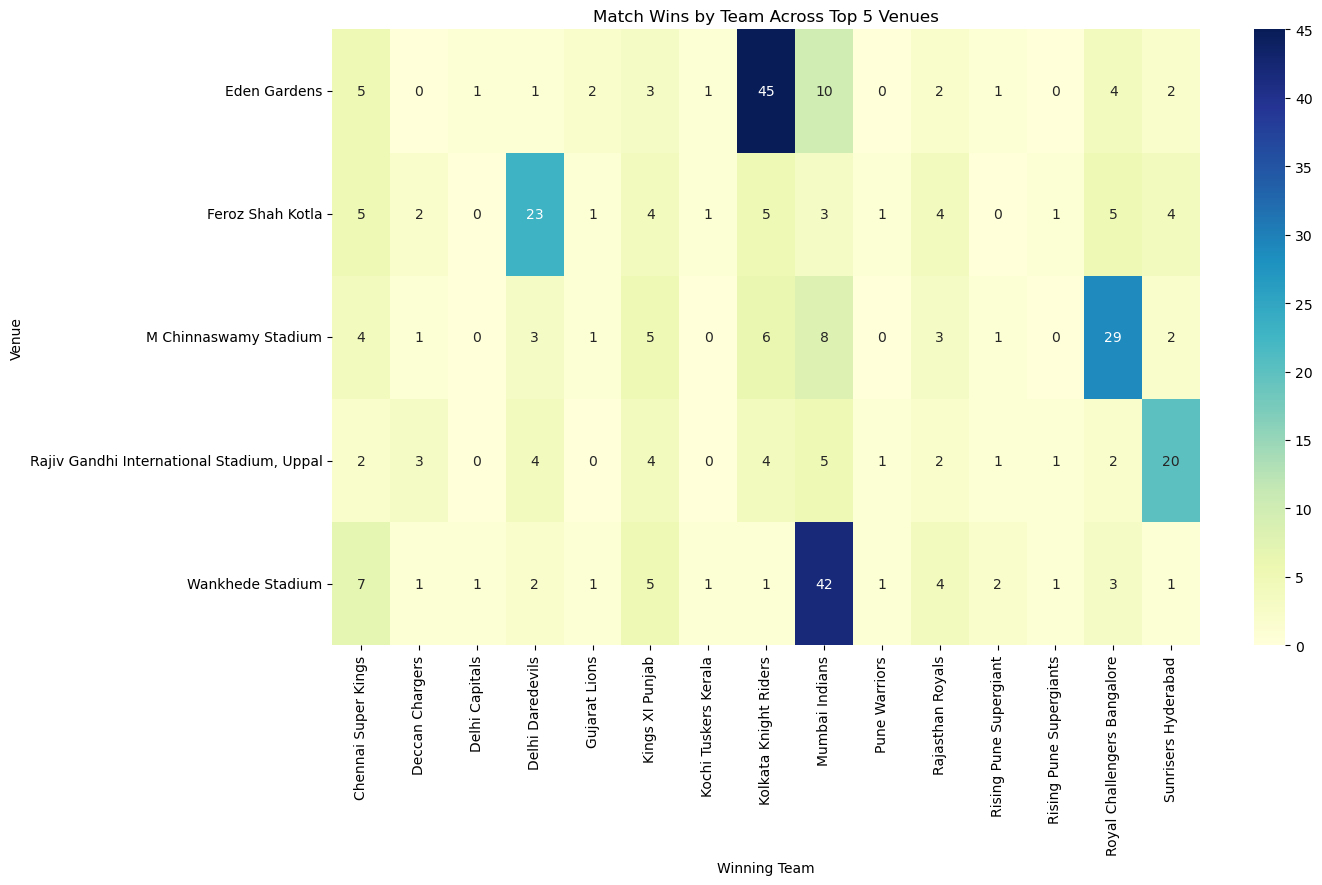

In [34]:
venue_winner = pd.crosstab(
    venue_data['venue'],
    venue_data['winner']
)

plt.figure(figsize=(14,8))

sns.heatmap(
    venue_winner,
    cmap='YlGnBu',
    annot=True,
    fmt='d'
)

plt.title('Match Wins by Team Across Top 5 Venues')
plt.xlabel('Winning Team')
plt.ylabel('Venue')

plt.show()

### Interpretation

The heatmap displays the number of victories achieved by different teams at the top five IPL venues.

A venue showing significantly higher win counts for a particular team may indicate a strong home advantage due to familiarity with pitch conditions and local support.

In [35]:
venue_winner.max(axis=1).sort_values(ascending=False)

venue
Eden Gardens                                 45
Wankhede Stadium                             42
M Chinnaswamy Stadium                        29
Feroz Shah Kotla                             23
Rajiv Gandhi International Stadium, Uppal    20
dtype: int64

# 9. Death Over Performance Analysis

The death overs (16–20) are often the most crucial phase of a T20 innings.

Teams attempt to maximize scoring during these overs, making them a key indicator of batting strength.

This analysis compares the death-over performance of the top six teams based on total runs scored during overs 16–20.

In [36]:
death_overs = deliveries[
    deliveries['over'].between(16, 20)
]

death_overs.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,total_runs_calc,is_boundary,over_phase
100,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,1,BB McCullum,Z Khan,DJ Hussey,1,0,1,NaN,0,NaN,not out,NaN,1,non-boundary,Death
101,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,2,DJ Hussey,Z Khan,BB McCullum,2,0,2,NaN,0,NaN,not out,NaN,2,non-boundary,Death
102,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,3,DJ Hussey,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,not out,NaN,1,non-boundary,Death
103,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,4,BB McCullum,Z Khan,DJ Hussey,6,0,6,NaN,0,NaN,not out,NaN,6,boundary,Death
104,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,5,BB McCullum,Z Khan,DJ Hussey,2,0,2,NaN,0,NaN,not out,NaN,2,non-boundary,Death


In [37]:
top_death_teams = (
    death_overs.groupby('batting_team')
    ['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(6)
)

top_death_teams

batting_team
Mumbai Indians                 9598
Chennai Super Kings            9061
Royal Challengers Bangalore    8417
Kolkata Knight Riders          8053
Rajasthan Royals               7281
Sunrisers Hyderabad            6237
Name: total_runs, dtype: int64

In [38]:
top_teams = top_death_teams.index.tolist()

death_overs_top = death_overs[
    death_overs['batting_team'].isin(top_teams)
]

In [39]:
death_over_runs = (
    death_overs_top.groupby(
        ['batting_team','match_id','inning','over']
    )['total_runs']
    .sum()
    .reset_index()
)

death_over_runs.head()

,batting_team,match_id,inning,over,total_runs
0,Chennai Super Kings,335983,1,16,14
1,Chennai Super Kings,335983,1,17,17
2,Chennai Super Kings,335983,1,18,15
3,Chennai Super Kings,335983,1,19,25
4,Chennai Super Kings,335989,1,16,10


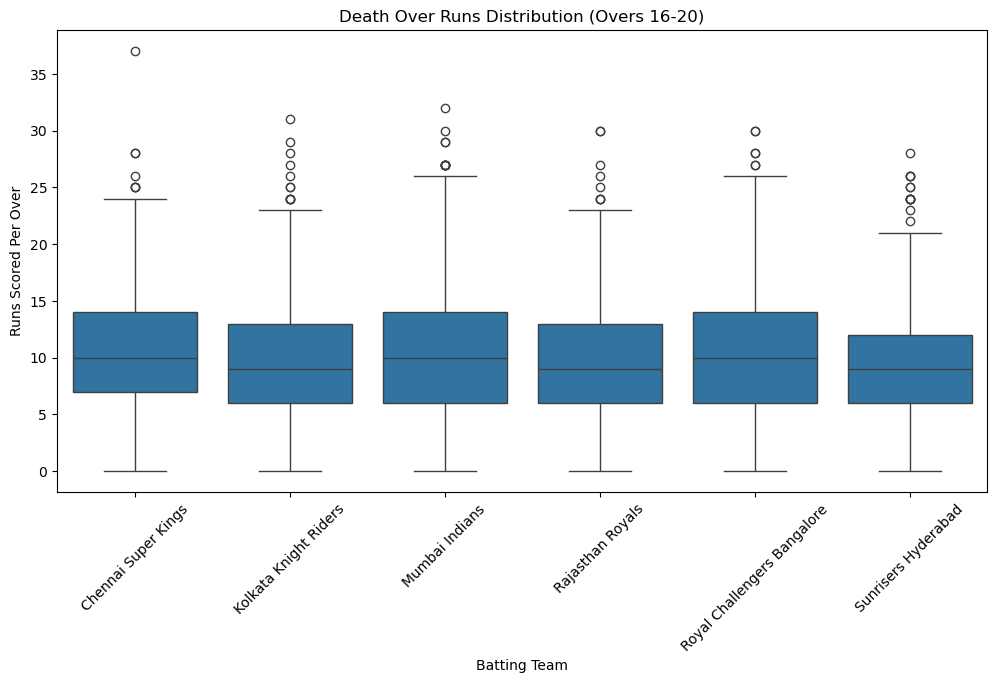

In [40]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=death_over_runs,
    x='batting_team',
    y='total_runs'
)

plt.title('Death Over Runs Distribution (Overs 16-20)')
plt.xlabel('Batting Team')
plt.ylabel('Runs Scored Per Over')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The box plot compares scoring distributions during death overs for the top six teams.

- Teams with a higher median score are generally more aggressive and effective in the final overs.
- Teams with a smaller spread (less variability) are more consistent.
- Teams with both a high median and large spread can be considered explosive but less predictable.

In [41]:
death_stats = (
    death_over_runs.groupby('batting_team')
    ['total_runs']
    .agg(['median','std'])
    .sort_values('median', ascending=False)
)

death_stats

,median,std
batting_team,,
Chennai Super Kings,10.0,5.146937
Mumbai Indians,10.0,5.592307
Royal Challengers Bangalore,10.0,5.567271
Kolkata Knight Riders,9.0,5.231524
Rajasthan Royals,9.0,5.071448
Sunrisers Hyderabad,9.0,4.974685


### Interpretation

- The team with the highest median score demonstrates the strongest average death-over batting performance.
- The standard deviation measures variability:
  - Lower values indicate consistency.
  - Higher values indicate explosive but unpredictable scoring.

Together, these metrics help identify the most reliable and most aggressive teams during the final overs.

<Axes: xlabel='season'>

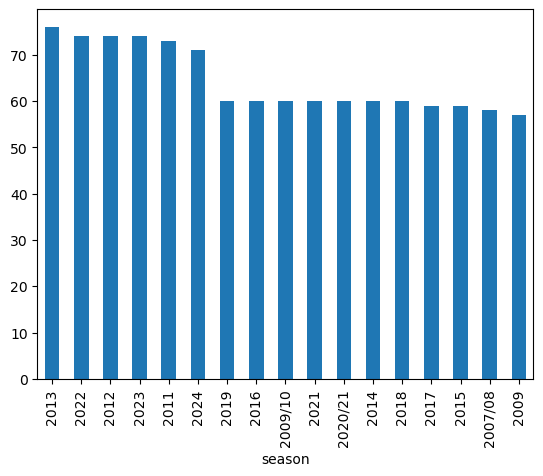

In [42]:
#Univarient
matches['season'].value_counts().plot(kind='bar')

<Axes: xlabel='toss_decision', ylabel='toss_win_match_win'>

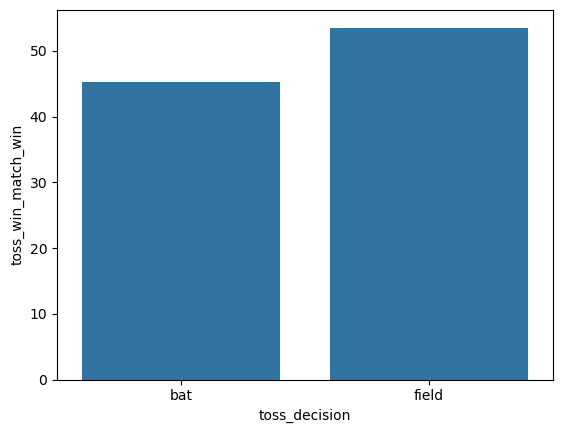

In [43]:
#bivarient
sns.barplot(
    data=decision_stats,
    x='toss_decision',
    y='toss_win_match_win'
)